Running simulations... (this may take a few seconds)
  → ε-Greedy (ε=0.01)
  → ε-Greedy (ε=0.10)
  → Optimistic Init (Q=5)
  → UCB (c=2)


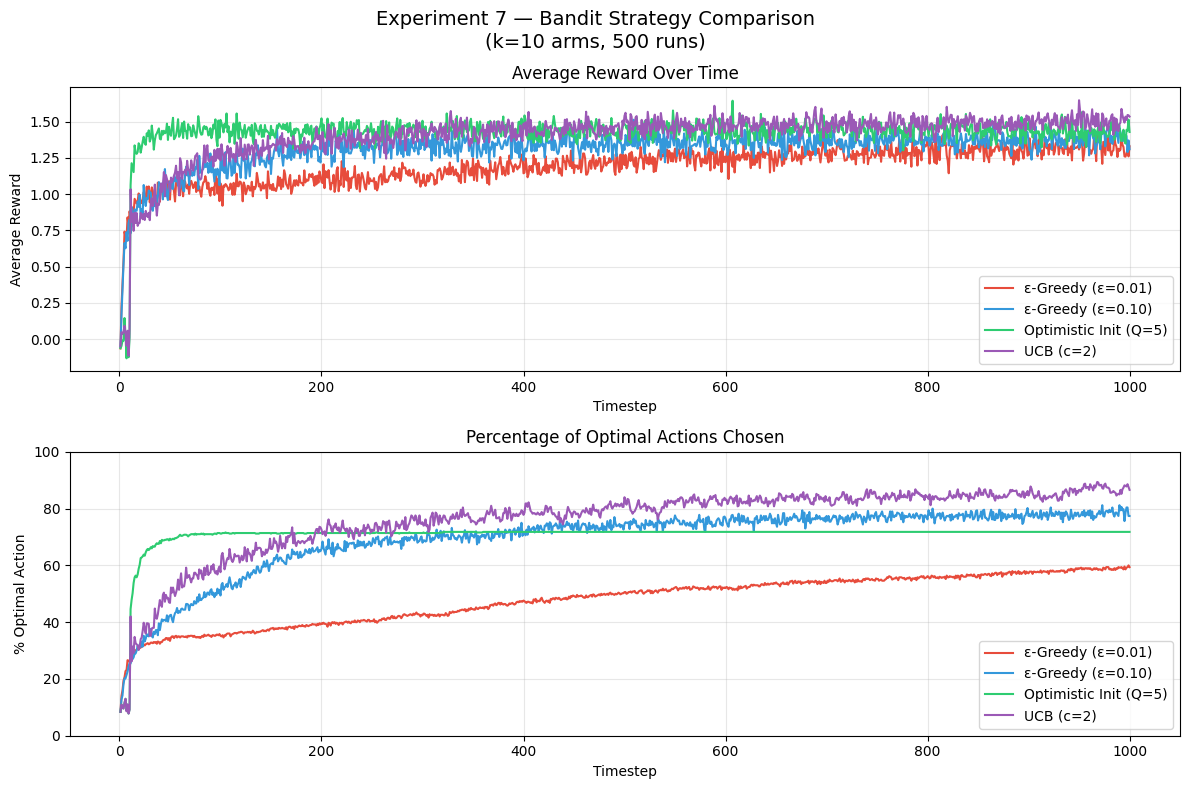


Done! Plot saved.


In [2]:
"""
Experiment 7 — Reinforcement Learning
Analyze & Visualize: ε-Greedy, Optimistic Initialization, and UCB
======================================================================
TEACHING GOAL:
    Understand how three exploration strategies behave differently
    on a k-armed bandit problem, and why each one works.
"""

import numpy as np
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────
# SECTION 1: The Bandit Environment
# ──────────────────────────────────────────────
# A "k-armed bandit" simulates k slot machines.
# Each arm has a TRUE mean reward (q*) sampled from N(0,1).
# When you pull an arm, you get a NOISY reward: q*(a) + noise.
# The agent doesn't know q* — it must LEARN by trying.

class KArmedBandit:
    def __init__(self, k=10, seed=42):
        np.random.seed(seed)
        self.k = k
        # True mean reward for each arm — unknown to the agent
        self.q_star = np.random.randn(k)   # shape (k,), e.g., [-0.3, 1.2, 0.5, ...]
        self.optimal_arm = np.argmax(self.q_star)  # the best arm (ground truth)

    def pull(self, arm):
        # Reward = true mean + Gaussian noise (unit variance)
        # WHY noise? Real environments are stochastic — same action ≠ same outcome
        return self.q_star[arm] + np.random.randn()


# ──────────────────────────────────────────────
# SECTION 2: ε-Greedy Agent
# ──────────────────────────────────────────────
# IDEA: With probability ε → explore (pick random arm)
#        With probability 1-ε → exploit (pick arm with highest Q)
#
# WHY IT WORKS: Guarantees we never fully stop exploring.
# WEAKNESS: Explores blindly — even clearly bad arms get pulled equally.
# ALTERNATIVE: Decay ε over time (ε-decay) so early exploration, later exploitation.

class EpsilonGreedy:
    def __init__(self, k, epsilon, init_value=0.0):
        self.k = k
        self.epsilon = epsilon
        self.Q = np.full(k, init_value, dtype=float)  # Q-value estimates
        self.N = np.zeros(k, dtype=int)               # pull count per arm

    def select_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.k)   # explore: random arm
        else:
            return np.argmax(self.Q)           # exploit: greedy arm

    def update(self, arm, reward):
        self.N[arm] += 1
        # Incremental mean update: Q ← Q + (1/N)(R - Q)
        # WHY incremental? Avoids storing all past rewards — O(1) memory
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]


# ──────────────────────────────────────────────
# SECTION 3: Optimistic Initialization
# ──────────────────────────────────────────────
# IDEA: Initialize all Q-values to a high number (e.g., 5.0).
#        When you pull an arm, its Q drops toward the true mean.
#        Arms that haven't been pulled stay "optimistically" high → get chosen.
#
# WHY IT WORKS: Over-optimism FORCES exploration in the beginning.
#               No explicit ε needed — curiosity is baked into Q-values.
# WEAKNESS: Only explores heavily at the START; not useful in non-stationary problems.

class OptimisticInit(EpsilonGreedy):
    # Reuses EpsilonGreedy but sets ε=0 (pure greedy) and high init_value
    # The high init_value does all the exploration work
    def __init__(self, k, init_value=5.0):
        super().__init__(k, epsilon=0.0, init_value=init_value)


# ──────────────────────────────────────────────
# SECTION 4: Upper Confidence Bound (UCB)
# ──────────────────────────────────────────────
# IDEA: Don't explore randomly. Explore *intelligently*.
#        Pick the arm that maximizes: Q(a) + c * sqrt(ln(t) / N(a))
#                                      ↑ exploit    ↑ explore bonus
#
# The bonus GROWS for arms pulled less often (small N(a))
# and SHRINKS as time passes and we gain confidence (large t).
#
# WHY IT WORKS: Based on Hoeffding's inequality — gives mathematically
#               principled upper bound on true Q-value.
# c (confidence level): higher c = more exploration.
# ALTERNATIVE: Thompson Sampling (Bayesian) — samples from posterior; harder to implement.

class UCB:
    def __init__(self, k, c=2.0):
        self.k = k
        self.c = c
        self.Q = np.zeros(k)
        self.N = np.zeros(k, dtype=int)
        self.t = 0   # total timesteps so far

    def select_action(self):
        self.t += 1
        # Pull each arm at least once first (N=0 → undefined bonus → force pull)
        unpulled = np.where(self.N == 0)[0]
        if len(unpulled) > 0:
            return unpulled[0]
        # UCB formula: Q + c * sqrt(ln(t) / N)
        ucb_values = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)
        return np.argmax(ucb_values)

    def update(self, arm, reward):
        self.N[arm] += 1
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]


# ──────────────────────────────────────────────
# SECTION 5: Simulation Runner
# ──────────────────────────────────────────────
# Run each agent for T timesteps across multiple bandit instances (runs).
# WHY multiple runs? A single run is noisy — averaging across runs
# gives stable performance curves (like taking expectation over environments).

def run_simulation(agent_fn, k=10, T=1000, runs=200):
    """
    agent_fn: callable that returns a fresh agent instance
    Returns: avg_reward (T,), optimal_action_pct (T,)
    """
    reward_log = np.zeros((runs, T))
    optimal_log = np.zeros((runs, T))

    for r in range(runs):
        bandit = KArmedBandit(k=k, seed=r)  # new bandit per run
        agent = agent_fn()                   # fresh agent per run

        for t in range(T):
            arm = agent.select_action()
            reward = bandit.pull(arm)
            agent.update(arm, reward)

            reward_log[r, t] = reward
            optimal_log[r, t] = 1 if arm == bandit.optimal_arm else 0

    return reward_log.mean(axis=0), optimal_log.mean(axis=0)


# ──────────────────────────────────────────────
# SECTION 6: Run All Agents
# ──────────────────────────────────────────────

k, T, runs = 10, 1000, 500

print("Running simulations... (this may take a few seconds)")

agents = {
    "ε-Greedy (ε=0.01)":    lambda: EpsilonGreedy(k, epsilon=0.01),
    "ε-Greedy (ε=0.10)":    lambda: EpsilonGreedy(k, epsilon=0.10),
    "Optimistic Init (Q=5)": lambda: OptimisticInit(k, init_value=5.0),
    "UCB (c=2)":             lambda: UCB(k, c=2.0),
}

results = {}
for name, fn in agents.items():
    print(f"  → {name}")
    avg_r, opt_pct = run_simulation(fn, k=k, T=T, runs=runs)
    results[name] = (avg_r, opt_pct)


# ──────────────────────────────────────────────
# SECTION 7: Visualization
# ──────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle("Experiment 7 — Bandit Strategy Comparison\n(k=10 arms, 500 runs)", fontsize=14)

colors = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6"]
steps = np.arange(1, T + 1)

for (name, (avg_r, opt_pct)), color in zip(results.items(), colors):
    axes[0].plot(steps, avg_r, label=name, color=color, linewidth=1.5)
    axes[1].plot(steps, opt_pct * 100, label=name, color=color, linewidth=1.5)

# Plot 1: Average Reward
axes[0].set_ylabel("Average Reward")
axes[0].set_xlabel("Timestep")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_title("Average Reward Over Time")

# Plot 2: % Optimal Action
axes[1].set_ylabel("% Optimal Action")
axes[1].set_xlabel("Timestep")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_title("Percentage of Optimal Actions Chosen")
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig("exp7.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nDone! Plot saved.")

# ──────────────────────────────────────────────
# EXPECTED OBSERVATIONS (Read after running)
# ──────────────────────────────────────────────
# ε=0.01: Learns slowly but eventually converges well (low random exploration)
# ε=0.10: Learns fast but plateaus below 100% (keeps exploring even when sure)
# Optimistic: Spikes early exploration, then converges like ε=0.01
# UCB: Fastest convergence — principled exploration beats random